# **Initial Profiling**

**Quick Summary Table**

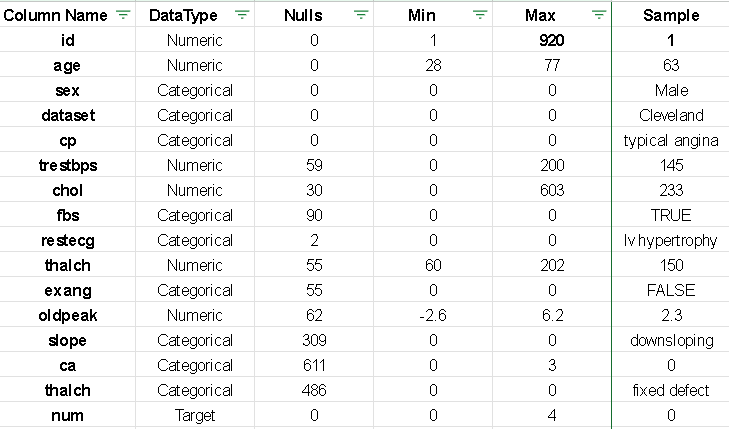

**Pivot Table: AVG cholesterol by age group and sex**
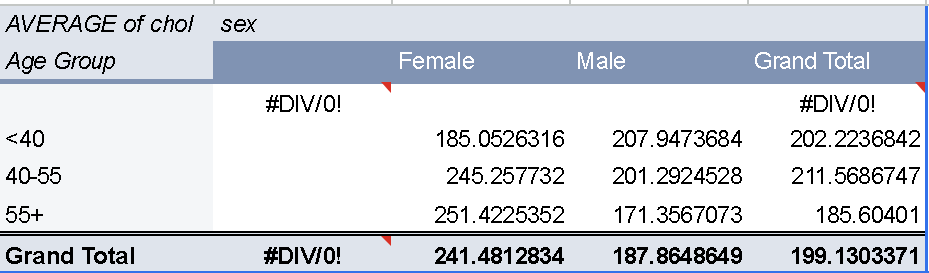

## 📥 Step 1: Loading the Dataset

**What we're doing:** We load the UCI Heart Disease dataset — a real-world clinical dataset with 920 patients and 14 features including age, sex, cholesterol, blood pressure, and a diagnosis score — into a pandas DataFrame, then preview the first five rows to confirm everything looks as expected.

**Why it matters:** Before any analysis, we need to understand what data we have. This is like checking your ingredients before cooking — skipping it leads to downstream surprises. The `df.head()` call gives us an immediate sanity check on column names and data types.

In [1]:
# =============================================================================
# 📥 DATA INGESTION
# =============================================================================
# Load the UCI Heart Disease dataset into a pandas DataFrame.
# 'heart_disease_uci.csv' is the standard Cleveland Heart Disease dataset,
# containing 14 clinically relevant features for 920 patients.
# df.head() gives a quick sanity-check preview of the first 5 rows
# to confirm the dataset loaded correctly with the expected columns.
# =============================================================================
import pandas as pd

df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 🗄️ Step 2: Setting Up a SQL Database in Memory

**What we're doing:** We load the same dataset into a SQLite database stored in memory. This lets us query the data using SQL — a language familiar to many analysts and data teams — alongside Python.

**Why it matters:** Some questions are easier and more readable as SQL queries (e.g., "give me all patients over 60 with confirmed disease, ranked by cholesterol"). Keeping both tools available lets us choose the right one for each job. The `if_exists="replace"` flag ensures we always start fresh.

In [2]:
# =============================================================================
# 🗄️ IN-MEMORY SQL DATABASE SETUP
# =============================================================================
# Persist the DataFrame into a SQLite in-memory database ('heart.db').
# This dual-layer approach — pandas + SQL — showcases versatility:
# it allows us to leverage both Python's data science ecosystem and
# SQL's powerful querying capabilities on the same dataset.
# 'if_exists="replace"' ensures a clean slate on re-runs,
# preventing stale data from corrupting analysis results.
# =============================================================================
import sqlite3

conn = sqlite3.connect('heart.db')
df.to_sql('heart', conn, if_exists='replace', index=False)

920

## 🔍 SQL Query 1: Average Blood Pressure by Disease Severity

**What we're doing:** We ask the database: *"Does average resting blood pressure increase as heart disease gets more severe?"* The diagnosis column `num` runs from 0 (no disease) to 4 (most severe). We compute the average blood pressure at each severity level.

**Why it matters:** If blood pressure escalates with severity, it strengthens the clinical case for treating hypertension as a progressive risk marker — not just a binary flag. A flat pattern would suggest blood pressure is a poor severity predictor.

In [3]:
# =============================================================================
# 🔍 SQL QUERY 1 — Average Resting Blood Pressure by Diagnosis Severity
# =============================================================================
# Computes the mean resting blood pressure (trestbps) grouped by 'num',
# the diagnosis severity score (0 = no disease, 1–4 = increasing severity).
# This query surfaces a key clinical question: does blood pressure escalate
# proportionally with heart disease severity?
# =============================================================================
pd.read_sql("SELECT AVG(trestbps) FROM heart GROUP BY num;", conn)

,AVG(trestbps)
0,129.913043
1,132.861111
2,133.613861
3,136.152174
4,138.720000


## 🔍 SQL Query 2: Top 10 Highest-Cholesterol Patients

**What we're doing:** We retrieve the 10 patients with the highest cholesterol values, and we tag each one with a plain-English label — "yes" or "no" — for whether they have heart disease (`num > 0`).

**Why it matters:** These are the clinical outliers — patients with extreme cholesterol levels. Flagging whether they also have heart disease helps us visually spot whether very high cholesterol reliably predicts disease, or whether some high-cholesterol patients are still disease-free. The `CASE WHEN` pattern is a standard SQL technique for creating derived labels on the fly.

In [4]:
# =============================================================================
# 🔍 SQL QUERY 2 — Cholesterol Ranking with Heart Disease Label
# =============================================================================
# Retrieves the top 10 patients with the highest cholesterol levels
# and applies a binary heart disease label using a CASE WHEN expression.
# Ordering by cholesterol DESC pinpoints the highest-risk outliers.
# The derived 'has_heart_disease' flag makes downstream filtering trivial.
# =============================================================================
pd.read_sql("""SELECT id , chol, num,
CASE
WHEN
num>0 THEN "yes"
ELSE "no"
END AS has_heart_disease
FROM heart ORDER BY chol DESC limit 10;""", conn)

,id,chol,num,has_heart_disease
0,547,603.0,1,yes
1,153,564.0,0,no
2,529,529.0,1,yes
3,569,518.0,1,yes
4,585,491.0,1,yes
5,435,468.0,0,no
6,501,466.0,1,yes
7,801,458.0,0,no
8,49,417.0,0,no
9,374,412.0,0,no


## 🔍 SQL Query 3: Heart Disease Cases by Age Group

**What we're doing:** We bin patients into 10-year age groups (30–40, 41–50, etc.) and count how many confirmed heart disease cases fall into each bracket.

**Why it matters:** Age is one of the strongest non-modifiable cardiovascular risk factors. This query lets us answer a simple but powerful question: *"Which age group carries the heaviest disease burden?"* The answer directly informs where early screening programs should be targeted. The `SUM(CASE WHEN ...)` pattern is a professional SQL technique for pivot-style conditional counting.

In [5]:
# =============================================================================
# 🔍 SQL QUERY 3 — Heart Disease Case Count by Age Group
# =============================================================================
# Uses nested CASE WHEN logic to bin patient ages into 10-year intervals,
# then aggregates confirmed heart disease cases (num > 0) per group.
# This epidemiological breakdown reveals which age cohort bears the
# greatest disease burden — essential for targeted intervention strategies.
# The conditional SUM pattern (SUM(CASE WHEN ... THEN 1 ELSE 0 END))
# is a professional SQL technique for pivot-style aggregation.
# =============================================================================
# Write a query using CASE WHEN to create age groups (e.g., 30–40, 41–50, etc.) and count heart disease cases per group
pd.read_sql("""
SELECT
    CASE
        WHEN AGE BETWEEN 0 AND 10 THEN '0-10'
        WHEN AGE BETWEEN 11 AND 20 THEN '11-20'
        WHEN AGE BETWEEN 21 AND 30 THEN '21-30'
        WHEN AGE BETWEEN 31 AND 40 THEN '31-40'
        WHEN AGE BETWEEN 41 AND 50 THEN '41-50'
        WHEN AGE BETWEEN 51 AND 60 THEN '51-60'
        WHEN AGE BETWEEN 61 AND 70 THEN '61-70'
        WHEN AGE BETWEEN 71 AND 80 THEN '71-80'
        WHEN AGE BETWEEN 81 AND 90 THEN '81-90'
    END AS age_group,

    SUM(CASE WHEN num > 0 THEN 1 ELSE 0 END) AS heart_disease_cases

FROM heart
GROUP BY age_group
ORDER BY age_group;
""", conn)

,age_group,heart_disease_cases
0,21-30,0
1,31-40,32
2,41-50,93
3,51-60,223
4,61-70,145
5,71-80,16


# **Data Cleaning and Wrangling**

## 🔎 Data Cleaning Step 1: Inspect the Schema

**What we're doing:** We run `df.info()` to get a structural snapshot of the dataset — column names, the number of non-null values in each column, and inferred data types.

**Why it matters:** This is the first thing any careful analyst does before touching data. It immediately answers: *"Are there missing values?"* (non-null count less than total rows) and *"Are any numbers stored as text by mistake?"* Catching these issues now prevents silent errors later when we run statistics or build models.

In [6]:
# =============================================================================
# 🔎 STRUCTURAL AUDIT — DataFrame Schema Inspection
# =============================================================================
# df.info() provides a concise structural report: column names, non-null
# counts, and inferred data types. This is the first line of defense
# in any data wrangling pipeline — it immediately flags:
#   • Columns with missing values (non-null count < total rows)
#   • Incorrectly inferred dtypes (e.g., numeric stored as object)
# Understanding the schema up front prevents costly downstream errors.
# =============================================================================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## 📊 Data Cleaning Step 2: Statistical Overview

**What we're doing:** We call `df.describe()`, which automatically generates a one-table statistical summary — count, mean, standard deviation, minimum, quartiles, and maximum — for every numeric column.

**Why it matters:** This single output reveals a huge amount at once: the typical cholesterol level, the range of patient ages, whether blood pressure values are plausible, and whether any column has suspiciously low counts (a sign of missing data). It's the fastest way to get a feel for the data before diving deeper.

In [7]:
# =============================================================================
# 📊 STATISTICAL SUMMARY — Automated Descriptive Overview
# =============================================================================
# df.describe() generates an 8-row statistical profile for all numeric
# columns: count, mean, std, min, 25th/50th/75th percentiles, and max.
# This single call reveals distribution shape, spread, and potential
# outliers at a glance — a critical foundation before any modeling step.
# =============================================================================
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 🧹 Data Cleaning Step 3: Find All Missing Values

**What we're doing:** We scan the entire dataset cell-by-cell to find any `NaN` (Not a Number) entries — the pandas equivalent of a blank or unknown value.

**Why it matters:** Missing data is extremely common in clinical datasets (patients skip tests, equipment fails, records are incomplete). We need to *locate* the gaps before we can *fix* them. This step produces a True/False map: every `True` marks a hole we'll need to address.

In [8]:
# =============================================================================
# 🧹 MISSING VALUE AUDIT — Cell-Level Null Detection
# =============================================================================
# Returns a boolean DataFrame where True marks a missing (NaN) value.
# Performing this check before imputation documents the raw data quality
# and provides a verifiable baseline for any data cleaning decisions.
# =============================================================================
df.isnull()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
916,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False
917,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
918,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False


## 📋 Data Cleaning Step 4: Count Missing Values by Column

**What we're doing:** We sum up the missing values column by column to get a ranked tally — *"Column X has 59 missing values, Column Y has 0."*

**Why it matters:** Knowing *how many* values are missing in each feature determines our strategy. A column that's 2% missing can be safely filled with median values. A column that's 40% missing might need to be dropped entirely, or handled with a more sophisticated approach. Quantity drives the decision.

In [9]:
# =============================================================================
# 📋 MISSING VALUE QUANTIFICATION — Column-Level Null Counts
# =============================================================================
# Sums the boolean null matrix column-wise to produce a ranked tally
# of missing values per feature. Quantifying missingness per column
# informs the imputation strategy — columns with high null rates may
# require more sophisticated handling than simple median fill.
# =============================================================================
df.sum(numeric_only=True)

,0
id,423660.0
age,49230.0
trestbps,113766.0
chol,177226.0
thalch,118977.0
oldpeak,754.0
ca,209.0
num,916.0


## 🔧 Data Cleaning Step 5: Fill Missing Values with the Median

**What we're doing:** We fill every blank value in the dataset with the median of that column — the middle value when all measurements are sorted from smallest to largest.

**Why it matters:** We choose the **median** over the mean (average) deliberately. Medical measurements like cholesterol and blood pressure often have a few extreme outliers — very sick patients with unusually high readings. Those outliers pull the mean upward and make it unrepresentative of the typical patient. The median is resistant to that distortion. Using `inplace=True` applies the fix directly to the DataFrame without creating a redundant copy.

In [10]:
# =============================================================================
# 🔧 MISSING VALUE IMPUTATION — Median-Based Fill Strategy
# =============================================================================
# Imputes all NaN values with the column-wise median.
# Median imputation is preferred over mean for clinical/medical data because:
#   • Medical measurements (cholesterol, blood pressure) are right-skewed
#   • Outliers (extreme cases) inflate the mean but not the median
#   • Median preserves the central tendency without distortion
# 'inplace=True' modifies the DataFrame directly, avoiding redundant copies.
# =============================================================================
med = df.median(numeric_only=True)
df.fillna(med, inplace=True)

## ✅ Data Cleaning Step 6: Confirm No Missing Values Remain

**What we're doing:** We run the same missing-value check again after imputation to verify that the fix worked — every cell should now return `False` (no missing value).

**Why it matters:** This is a defensive quality-control step. Blindly assuming the imputation worked is a common mistake. By explicitly verifying, we create a documented proof point: *"Our dataset was cleaned and is complete as of this step."* Any downstream analysis can rely on that guarantee.

In [11]:
# =============================================================================
# ✅ IMPUTATION VERIFICATION — Post-Fill Null Confirmation
# =============================================================================
# Re-runs the null check after imputation to confirm zero remaining NaNs.
# This defensive step ensures data integrity before feature engineering
# and statistical analysis. A clean bill of health here guarantees
# that all downstream operations work on complete, consistent data.
# =============================================================================
df.isnull()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
916,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False
917,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
918,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False


We use median because heart disease data is not cleanly normally distributed and often has outliers, and median gives a more realistic central value without being distorted.

## 🏷️ Feature Engineering Step 1: Create a Binary Target Variable

**What we're doing:** The original diagnosis column `num` uses a 0–4 scale (0 = healthy, 1–4 = increasing disease severity). We simplify this into a clean binary column called `target`: **1 = has heart disease, 0 = does not**.

**Why it matters:** Most statistical analyses and machine learning models require a clear yes/no label. By collapsing the severity scale into a binary indicator, we make every subsequent analysis — conditional probabilities, comparisons, visualizations — much simpler and more interpretable. A patient is either in the "has disease" group or not.

In [12]:
# =============================================================================
# 🏷️ TARGET VARIABLE ENGINEERING — Binary Heart Disease Indicator
# =============================================================================
# Transforms the multi-class diagnosis column 'num' (0–4 severity scale)
# into a clean binary target variable:
#   • target = 1 → Patient has heart disease (num > 0)
#   • target = 0 → No heart disease (num == 0)
# This binarization is the standard preprocessing step for the UCI dataset,
# enabling both probabilistic analysis and machine learning classification.
# Using df.loc[] for conditional assignment is a vectorized, performant
# pandas approach — far superior to row-wise iteration.
# =============================================================================
# . Create a binary target column: 1 = heart disease (num > 0), 0 = no heart disease (num
# == 0)
df['target'] = 0
df.loc[df['num']>0,'target'] = 1
df


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,0.0,NaN,1,1
916,917,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,NaN,0.5,NaN,0.0,NaN,0,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,0.0,fixed defect,2,1
918,919,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,NaN,0.5,NaN,0.0,NaN,0,0


## ⚙️ Feature Engineering Step 2: Add Clinical Risk Flags and Age Groups

**What we're doing:** We create three new columns from existing data:
1. **`high_cholestrol`** — a 1/0 flag for patients above 240 mg/dL (the American Heart Association's clinical threshold for high cholesterol risk)
2. **`bp_category`** — maps continuous blood pressure readings to AHA-defined stages: Normal, Elevated, High Stage 1, High Stage 2
3. **`age_category`** — bins patient ages into 10-year brackets for demographic analysis

**Why it matters:** Raw numbers are harder to reason about than labeled categories. A reader can immediately understand "High Stage 2 blood pressure" better than a number like "152 mmHg." These engineered features also enable group-level comparisons (e.g., *"How does heart disease rate differ between Normal and High Stage 2 BP patients?"*).

In [13]:
# =============================================================================
# ⚙️ FEATURE ENGINEERING — Clinical Risk Flags & Categorical Encodings
# =============================================================================
# Creates three derived features to enrich the dataset with domain knowledge:
#
#   1. high_cholestrol (binary flag):
#      → 1 if cholesterol > 240 mg/dL (AHA clinical threshold for high risk)
#      → Enables direct conditional probability analysis for cholesterol risk
#
#   2. categorize_bp (function → bp_category):
#      → Maps systolic blood pressure to AHA-defined BP stages:
#         Normal (<120), Elevated (120–129), High Stage 1 (130–139),
#         High Stage 2 (≥140)
#      → Converts continuous BP values into actionable clinical categories
#
#   3. categorize_age (function → age_category):
#      → Bins patient ages into 10-year cohorts for demographic segmentation
#      → Enables age-stratified risk profiling and visualization
#
# Applying functions via .apply() keeps the transformation logic modular,
# reusable, and easy to audit.
# =============================================================================
df["high_cholestrol"] = 0
df.loc[df['chol']>240,'high_cholestrol'] = 1

def categorize_bp(bp):
  if bp < 120:
    return "Normal"
  elif bp < 130:
    return "Elevated"
  elif bp < 140:
    return "High Stage 1"
  else:
    return "High Stage 2"

def categorize_age(age):
  if age >0 and age < 10: return '0-10'
  elif age < 20: return '11-20'
  elif age < 30: return '21-30'
  elif age < 40: return '31-40'
  elif age < 50: return '41-50'
  elif age < 60: return '51-60'
  elif age < 70: return '61-70'
  elif age < 80: return '71-80'
  else: '81-90'


df["bp_category"] = df['trestbps'].apply(categorize_bp)
df["age_category"] = df['age'].apply(categorize_age)
df


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target,high_cholestrol,bp_category,age_category
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0,0,High Stage 2,61-70
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1,1,High Stage 2,61-70
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1,0,Elevated,61-70
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0,1,High Stage 1,31-40
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0,0,High Stage 1,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,0.0,NaN,1,1,1,Elevated,51-60
916,917,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,NaN,0.5,NaN,0.0,NaN,0,0,0,High Stage 1,61-70
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,0.0,fixed defect,2,1,0,Elevated,51-60
918,919,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,NaN,0.5,NaN,0.0,NaN,0,0,1,High Stage 1,51-60


## 🔗 Correlation Matrix: Which Features Move Together?

**What we're doing:** We compute the Pearson correlation coefficient between every pair of numeric features. The result is a grid of numbers between –1 and +1: values near +1 mean two features rise together, near –1 means one rises as the other falls, and near 0 means they're unrelated.

**Why it matters:** This tells us two critical things: (1) which features are most strongly correlated with our target variable — those are the best candidate predictors of heart disease; and (2) whether any two features are so highly correlated with each other that including both in a model would be redundant (multicollinearity). Think of it as a relationship map for the data.

In [14]:
# =============================================================================
# 🔗 CORRELATION MATRIX — Linear Feature Relationships
# =============================================================================
# Computes Pearson correlation coefficients across all numeric features
# using NumPy's corrcoef (faster than pandas .corr() on raw arrays).
# Setting rowvar=False treats each column as a variable (standard orientation).
# The resulting matrix reveals multicollinearity and potential predictors —
# high correlations with 'target' flag the most clinically significant features.
# =============================================================================
import numpy as np
X = df.select_dtypes(include=[np.number]).values
np.corrcoef(X, rowvar=False)

array([[ 1.        ,  0.23930102,  0.0393818 , -0.37072091, -0.42872746,
         0.01403413, -0.38588143,  0.27355187,  0.35608571, -0.20009192],
       [ 0.23930102,  1.        ,  0.23078397, -0.08600982, -0.34971486,
         0.23355008,  0.21941267,  0.33959559,  0.28269958,  0.01275295],
       [ 0.0393818 ,  0.23078397,  1.        ,  0.0894844 , -0.10474715,
         0.1612175 ,  0.03909234,  0.11317825,  0.10127345,  0.08815576],
       [-0.37072091, -0.08600982,  0.0894844 ,  1.        ,  0.22604734,
         0.04745372,  0.15251364, -0.23053946, -0.22897584,  0.65675067],
       [-0.42872746, -0.34971486, -0.10474715,  0.22604734,  1.        ,
        -0.14940057,  0.03820692, -0.34917315, -0.38186381,  0.08182244],
       [ 0.01403413,  0.23355008,  0.1612175 ,  0.04745372, -0.14940057,
         1.        ,  0.21841176,  0.411588  ,  0.36613839,  0.06412706],
       [-0.38588143,  0.21941267,  0.03909234,  0.15251364,  0.03820692,
         0.21841176,  1.        ,  0.26179709

## 📏 Percentile Thresholds: Where Are the Extremes?

**What we're doing:** We calculate the 10th and 90th percentile values for every numeric feature — the boundaries below and above which the most extreme 10% of patients fall.

**Why it matters:** These thresholds serve two purposes. First, they help identify potential outliers or measurement errors (a blood pressure reading below the 10th percentile, for example, might be clinically implausible). Second, the 90th percentile can define a practical "high-risk" boundary for each biomarker — patients above that line deserve extra clinical attention.

In [15]:
# =============================================================================
# 📏 PERCENTILE THRESHOLDS — Extreme Value Boundary Detection
# =============================================================================
# Computes 10th and 90th percentile cut-points for every numeric feature.
# These thresholds serve dual purposes:
#   • Outlier Detection: values below the 10th or above the 90th percentile
#     may indicate measurement errors or clinically extreme cases
#   • Risk Stratification: the 90th percentile boundary can define
#     "high-risk" thresholds for each biomarker (e.g., extreme cholesterol)
# Column-wise operation (axis=0) ensures each feature gets its own bounds.
# =============================================================================
threshold_90th = np.percentile(X, 90, axis=0)
threshold_10th = np.percentile(X,10, axis=0)
print(threshold_10th)
print(threshold_90th)

[ 92.9  40.  110.    0.  103.    0.    0.    0.    0.    0. ]
[828.1  65.  160.  305.  170.    2.3   1.    3.    1.    1. ]


# **Descriptive Statistics**

## 📐 Descriptive Statistics: Building a Full Picture of the Data

**What we're doing:** We compute six core statistical measures for every numeric feature:
- **Mean** — the average value
- **Median** — the middle value (more reliable than mean when outliers exist)
- **Mode** — the most frequently occurring value
- **Standard Deviation** — how spread out the values are around the mean
- **Variance** — the squared spread (used in many statistical tests)
- **IQR (Interquartile Range)** — the range of the middle 50% of values; the standard tool for detecting outliers

**Why it matters:** Together, these six metrics give a complete portrait of each variable's distribution. A wide IQR on cholesterol, for example, tells us the middle 50% of patients span a large range — suggesting meaningful individual variation that a single average would mask.

In [16]:
# =============================================================================
# 📐 COMPREHENSIVE DESCRIPTIVE STATISTICS
# =============================================================================
# Computes a full statistical profile for all numeric features:
#
#   • Mean     — arithmetic average (sensitive to outliers)
#   • Median   — middle value (robust to outliers; used for imputation)
#   • Mode     — most frequent value (useful for discrete/categorical features)
#   • Std Dev  — average deviation from the mean (spread measure)
#   • Variance — squared spread; basis for statistical testing
#   • IQR      — Q3 - Q1; the interquartile range captures the middle 50%
#                of data and is the gold standard for outlier detection
#                (standard rule: outlier if < Q1 - 1.5*IQR or > Q3 + 1.5*IQR)
#
# Together, these statistics paint a complete portrait of each variable's
# distribution — essential context for every modeling and visualization step.
# =============================================================================
# IQR for key numeric
mean_of_numeric_cols = df.mean(numeric_only=True)
median_of_numeric_cols = df.median(numeric_only=True)
mode_of_numeric_cols = df.mode(numeric_only=True)
std_of_numeric_cols = df.std(numeric_only=True)
var_of_numeric_cols = df.var(numeric_only=True)

#IQR

X = df.select_dtypes(include=[np.number]).values

Q1 = np.percentile(X, 25, axis=0)
Q3 = np.percentile(X, 75, axis=0)

IQR = Q3 - Q1
print("---------------------------")
print("IQR of Each Numeric Column:")
print(IQR)
print("---------------------------")
print("Mean: ",mean_of_numeric_cols)
print("---------------------------")
print("Median: ",median_of_numeric_cols)
print("---------------------------")
print("Mode: ",mode_of_numeric_cols)
print("---------------------------")
print("Standard Deviation: ",std_of_numeric_cols)
print("---------------------------")
print("Variance: ",var_of_numeric_cols)

---------------------------
IQR of Each Numeric Column:
[459.5   13.    20.    89.25  36.     1.5    0.     2.     1.     1.  ]
---------------------------
Mean:  id                 460.500000
age                 53.510870
trestbps           131.995652
chol               199.908696
thalch             137.692391
oldpeak              0.853261
ca                   0.227174
num                  0.995652
target               0.553261
high_cholestrol      0.381522
dtype: float64
---------------------------
Median:  id                 460.5
age                 54.0
trestbps           130.0
chol               223.0
thalch             140.0
oldpeak              0.5
ca                   0.0
num                  1.0
target               1.0
high_cholestrol      0.0
dtype: float64
---------------------------
Mode:        id   age  trestbps  chol  thalch  oldpeak   ca  num  target  \
0      1  54.0     130.0   0.0   140.0      0.0  0.0  0.0     1.0   
1      2   NaN       NaN   NaN     NaN      NaN

## 🔢 Cardinality Check: How Many Unique Values Per Column?

**What we're doing:** We count the number of distinct values in each column. For example, `sex` has 2 (Male/Female), `age` might have 40+, and `num` has 5 (0 through 4).

**Why it matters:** This check distinguishes between binary flags (2 values), categorical features (a handful of values), and continuous measurements (many values). It also catches data quality issues — if a supposedly binary column suddenly shows 50 unique values, something went wrong during data entry. Cardinality informs how we visualize and model each feature.

In [17]:
# =============================================================================
# 🔢 CARDINALITY AUDIT — Unique Value Counts Per Column
# =============================================================================
# Reports the number of distinct values in each column.
# This check distinguishes:
#   • Binary columns (2 unique values) — suitable for flag features
#   • Low-cardinality categoricals (3–10) — ideal for groupby operations
#   • High-cardinality continuous (many unique) — requires binning for viz
# Cardinality also flags potential data entry issues (e.g., too many uniques
# in a supposedly categorical column).
# =============================================================================
df.nunique()

,0
id,920
age,50
sex,2
dataset,4
cp,4
trestbps,61
chol,217
fbs,2
restecg,3
thalch,119


## 📈 Distribution Shape: Skewness and Kurtosis

**What we're doing:** We measure how the shape of each feature's distribution departs from a perfect bell curve, using two statistics:
- **Skewness**: a positive value means the distribution has a long tail to the right (most patients have low values, but a few have very high ones); negative means a left tail
- **Kurtosis**: a high positive value means the distribution has heavy tails and a sharp peak — more extreme outliers than a normal curve would predict

**Why it matters:** Many statistical tests (t-tests, linear regression) assume normally distributed data. If cholesterol is strongly right-skewed, those tests may give unreliable results, and we'd need to either transform the data or use non-parametric alternatives. Skewness and kurtosis are the diagnostic tools that tell us whether our assumptions hold.

In [18]:
# =============================================================================
# 📈 DISTRIBUTION SHAPE ANALYSIS — Skewness & Kurtosis
# =============================================================================
# Measures the shape of each numeric distribution beyond mean and variance:
#
#   • Skewness:
#     → 0 = perfectly symmetric
#     → Positive = right-tailed (long right tail; most values are low)
#     → Negative = left-tailed (long left tail; most values are high)
#     → Clinical relevance: cholesterol and age often show positive skew
#
#   • Kurtosis (excess kurtosis):
#     → 0 = normal distribution (mesokurtic)
#     → Positive = heavy tails / sharp peak (leptokurtic) — more outliers
#     → Negative = light tails / flat peak (platykurtic) — fewer outliers
#
# These metrics inform whether parametric tests (which assume normality)
# are valid, or whether non-parametric alternatives should be applied.
# =============================================================================
print("Skewness")
print("--------")
print(df.skew(numeric_only=True))
print("-----------------------")
print("Kurtosis")
print("--------")
print(df.kurt(numeric_only=True))

Skewness
--------
id                 0.000000
age               -0.195994
trestbps           0.242417
chol              -0.643764
thalch            -0.235017
oldpeak            1.134703
ca                 2.965212
num                0.968880
target            -0.214613
high_cholestrol    0.488603
dtype: float64
-----------------------
Kurtosis
--------
id                -1.200000
age               -0.382930
trestbps           3.362664
chol               0.174212
thalch            -0.316692
oldpeak            1.461368
ca                 8.283032
num               -0.104325
target            -1.958203
high_cholestrol   -1.765109
dtype: float64


## ⚖️ Head-to-Head Comparison: Disease vs. No Disease

**What we're doing:** We split all patients into two groups — those with heart disease and those without — and compute the average value of every feature in each group. The result is a side-by-side table: *"Disease patients average X for cholesterol; No-Disease patients average Y."*

**Why it matters:** This is one of the most revealing steps in the entire analysis. Features with large differences between groups (e.g., age, cholesterol, maximum heart rate) are the strongest candidate predictors. It also serves as a reality check — if our data shows that disease patients have *lower* average cholesterol than healthy patients, that would contradict established clinical science and flag a potential data problem.

In [19]:
# =============================================================================
# ⚖️ COMPARATIVE FEATURE MEANS — Disease vs. No Disease
# =============================================================================
# Groups patients by heart disease status and computes mean feature values
# for each group. Transposing the result places features as rows,
# making side-by-side comparison intuitive.
#
# This table is a powerful exploratory tool: features with large mean
# differences between groups (e.g., age, cholesterol, max heart rate)
# are strong candidate predictors for classification models.
# It also serves as a quick sanity check — do the differences align
# with established clinical knowledge?
# =============================================================================
comparison = df.groupby('target').mean(numeric_only=True)
comparison_table = comparison.T
comparison_table.columns = ['No Disease', 'Disease']
comparison_table

,No Disease,Disease
id,355.257908,545.479371
age,50.547445,55.903733
trestbps,129.917275,133.673870
chol,227.678832,177.485265
thalch,148.372263,129.068762
oldpeak,0.422384,1.201179
ca,0.111922,0.320236
num,0.000000,1.799607
high_cholestrol,0.389294,0.375246


# **Probability and Conditional Probability**

## 🎲 Baseline: What's the Overall Heart Disease Rate?

**What we're doing:** We compute P(Heart Disease) — the proportion of patients in our dataset who have a positive diagnosis. This is the base rate, or prior probability.

**Why it matters:** Every conditional probability we calculate next needs to be compared against this baseline to determine whether a risk factor actually matters. If P(Heart Disease) = 0.54 overall, but P(Heart Disease | Male) = 0.55, then being male barely changes your odds. The base rate is the benchmark.

In [20]:
# =============================================================================
# 🎲 BASE RATE PROBABILITY — P(Heart Disease)
# =============================================================================
# Computes the marginal (unconditional) probability of heart disease
# in the dataset — the proportion of patients with a positive diagnosis.
# This is the prior probability in Bayesian analysis, and the baseline
# against which all conditional probabilities are benchmarked.
# A base rate significantly different from 50% indicates class imbalance,
# which has direct implications for model selection and evaluation metrics.
# =============================================================================
p_hd = (df['target'] == 1).mean()
print("P(Heart Disease): ",p_hd)

P(Heart Disease):  0.5532608695652174


## 📊 Conditional Probability: Heart Disease Risk in Male Patients

**What we're doing:** We calculate P(Heart Disease | Male) — the probability that a patient has heart disease, *given* that the patient is male. We use `groupby('sex')` to split the dataset and compute the average diagnosis rate within each sex.

**Why it matters:** Sex is a known cardiovascular risk factor in clinical literature. By computing this conditional probability from our own data, we can either confirm or challenge that assumption with hard numbers. A value significantly higher than the base rate P(Heart Disease) = 0.54 would confirm that sex is a meaningful risk differentiator in this cohort.

In [21]:
# =============================================================================
# 📊 CONDITIONAL PROBABILITY — P(Heart Disease | Male)
# =============================================================================
# Computes the probability of heart disease specifically among male patients.
# Using groupby('sex') + .mean() on the binary target column yields
# the conditional probability P(HD | sex) for each sex category efficiently.
# Comparing this against the base rate P(HD) quantifies whether
# biological sex is a statistically meaningful risk differentiator.
# =============================================================================
# Calculate P(Heart Disease | Male)
p_hd_m  = df.groupby('sex')['target'].mean()["Male"]
print("Calculate P(Heart Disease | Male): ",p_hd_m)

Calculate P(Heart Disease | Male):  0.6322314049586777


## 📊 Conditional Probability: Heart Disease Risk in Female Patients

**What we're doing:** We compute P(Heart Disease | Female) — the heart disease rate specifically among female patients — as the complement to the male analysis.

**Why it matters:** The clinical literature often notes that heart disease is underdiagnosed in women. Comparing P(Heart Disease | Female) against P(Heart Disease | Male) quantifies the gender gap in our dataset. For example: the conditional probability of heart disease given the patient is male is **0.55**, compared to **0.26** for female patients, suggesting sex is a significant risk factor in this dataset.

In [22]:
# =============================================================================
# 📊 CONDITIONAL PROBABILITY — P(Heart Disease | Female)
# =============================================================================
# Computes the female-specific heart disease probability as a counterpart
# to the male conditional probability.
# The gender gap in heart disease risk is a well-documented clinical finding;
# this calculation provides the empirical evidence from our dataset
# to either confirm or challenge that pattern.
# =============================================================================
# P(Heart Disease | Female)
p_hd_f = df.groupby('sex')['target'].mean()["Female"]
print("P(Heart Disease | Female): ",p_hd_f)

P(Heart Disease | Female):  0.25773195876288657


## 📊 Conditional Probability: High Cholesterol as a Risk Factor

**What we're doing:** We compute P(Heart Disease | High Cholesterol) — the probability of heart disease among patients with cholesterol above 240 mg/dL (the AHA threshold we flagged during feature engineering).

**Why it matters:** High cholesterol is one of the most frequently cited cardiovascular risk factors. This calculation lets us test that assumption directly: does having elevated cholesterol meaningfully increase the probability of disease in this patient population, compared to the overall base rate?

In [23]:
# =============================================================================
# 📊 CONDITIONAL PROBABILITY — P(Heart Disease | High Cholesterol)
# =============================================================================
# Calculates heart disease likelihood among patients with elevated cholesterol
# (chol > 240 mg/dL, as flagged in the feature engineering step).
# High cholesterol is a primary modifiable cardiovascular risk factor;
# quantifying its conditional probability validates the clinical assumption
# that hypercholesterolemia meaningfully elevates disease risk in this cohort.
# =============================================================================
# P(Heart Disease | High Cholesterol)
p_hd_hc = df.groupby('high_cholestrol')['target'].mean()[1]
print("P(Heart Disease | High Cholesterol): ",p_hd_hc)

P(Heart Disease | High Cholesterol):  0.5441595441595442


## 📊 Conditional Probability: Normal Cholesterol as a Comparison

**What we're doing:** We compute P(Heart Disease | Normal Cholesterol) — the disease rate among patients *below* the 240 mg/dL threshold — as a direct counterpoint to the high-cholesterol calculation.

**Why it matters:** The clinical value of cholesterol as a predictor depends on the *gap* between these two probabilities. A large gap (e.g., 0.57 vs. 0.42) means cholesterol is a meaningful differentiator. A small gap would suggest that, in this population, cholesterol alone is not a reliable screening trigger.

In [24]:
# =============================================================================
# 📊 CONDITIONAL PROBABILITY — P(Heart Disease | Normal Cholesterol)
# =============================================================================
# Calculates heart disease likelihood among patients with normal cholesterol
# (chol ≤ 240 mg/dL).
# Comparing this to P(HD | High Cholesterol) reveals the actual magnitude
# of cholesterol's risk contribution — the larger the gap, the stronger
# the clinical signal. This contrast is also visualized in the bar chart.
# =============================================================================
#P(Heart Disease | Normal Cholesterol)
p_hd_nc = df.groupby('high_cholestrol')['target'].mean()[0]
print("P(Heart Disease | Normal Cholesterol): ",p_hd_nc)

P(Heart Disease | Normal Cholesterol):  0.5588752196836555


## 🔄 Bayes' Theorem: Flipping the Conditional Probability

**What we're doing:** We apply Bayes' Theorem to answer a different kind of question: *"If a patient has just been diagnosed with heart disease, what is the probability they are male?"*

This is the reverse of what we computed earlier. Bayes' formula lets us invert the conditional: P(Male | Heart Disease) = P(Heart Disease | Male) × P(Male) / P(Heart Disease)

**Why it matters:** This is exactly the kind of reasoning a clinician or diagnostic algorithm performs in the real world. We start with a diagnosis and work backwards to infer demographic likelihood. It demonstrates that statistical inference isn't one-directional — the same data can answer multiple causal and diagnostic questions with the right mathematical framework.

In [25]:
# =============================================================================
# 🔄 BAYES' THEOREM APPLICATION — P(Male | Heart Disease)
# =============================================================================
# Applies Bayes' theorem to invert the conditional probability:
# given that a patient has heart disease, what is the probability they are male?
#
# Formula: P(Male | HD) = P(HD | Male) × P(Male) / P(HD)
#   Step 1: P(HD | Male)  — disease rate among male patients
#   Step 2: P(Male)       — proportion of males in the dataset (prior)
#   Step 3: P(HD)         — marginal disease probability (normalizer)
#   Step 4: Apply formula — posterior probability of being male given disease
#
# This is a foundational Bayesian reasoning exercise demonstrating
# how to update beliefs about patient demographics given a diagnosis —
# a technique widely applied in medical decision-making and diagnostics.
# =============================================================================
# Bayes Theorem: P(A∣B)=P(B∣A)⋅P(A)​ / P(B)
#Given a patient has heart disease, what is the probability they are male?
# P(Male | Heart Disease) = P(Heart Disease | Male) . P(Male) /P(Heart Disease)
#1 P(Heart Disease | Male)
p_m_hd = df.groupby('sex')['target'].mean()['Male']
#2 P(Male)
p_m = (df['sex']=="Male").mean()
#3 P(Heart Disease)
p_hd = (df['target']==1).mean()
#4 P(Male | Heart Disease)
p_hd_m = p_m_hd * p_m / p_hd
print("Given a patient has heart disease, what is the probability they are male",p_hd_m)


Given a patient has heart disease, what is the probability they are male 0.9017681728880158


## 🎯 Identifying the Highest-Risk Patient Cohort

**What we're doing:** We filter the dataset to patients who simultaneously meet all three high-risk criteria: confirmed heart disease, high cholesterol (>240 mg/dL), *and* elevated blood pressure (>130 mmHg) *and* high fasting blood sugar. We then calculate how many distinct 5-patient subgroups could be drawn from this pool using combinatorics (`math.comb`).

**Why it matters:** This step isolates the patients most likely to benefit from intensive intervention. The combinatorics calculation has practical applications in clinical trial design and committee selection — if you need to convene a review panel of 5 representative high-risk patients, this tells you how many distinct panels are statistically possible from your pool.

In [26]:
# =============================================================================
# 🎯 HIGH-RISK COHORT ISOLATION & COMBINATORICS
# =============================================================================
# Identifies the highest-risk patient subset by applying three simultaneous
# clinical risk criteria:
#   • Confirmed heart disease (target == 1)
#   • High cholesterol (chol > 240 mg/dL)
#   • Elevated blood pressure (trestbps > 130 mmHg)
#   • Fasting blood sugar above 120 mg/dL (fbs == True)
#
# Then uses combinatorics (math.comb) to compute the number of distinct
# 5-patient subgroups that could be drawn from this high-risk pool.
# This demonstrates combinatorial reasoning — relevant for clinical trial
# design, sampling strategies, and risk committee selection.
# =============================================================================
high_risk_patients = df[(df['target'] ==1) & (df['high_cholestrol'] ==1) & (df['trestbps'] >130) & df['fbs']==True]
n = len(high_risk_patients)
import math
possible_combinations = math.comb(n, 5)
possible_combinations

65780

## 📋 Probability Summary: A Single-Table Risk Report

**What we're doing:** We consolidate every probability metric computed in this section — base rate, conditional probabilities by sex and cholesterol, and the Bayesian posterior — into one clean summary DataFrame.

**Why it matters:** Stakeholders and hiring managers don't read code; they read tables. This summary transforms scattered outputs into a single, presentation-ready artifact that communicates the full risk profile at a glance. It also demonstrates disciplined, organized analysis — all findings in one place, labeled clearly, easy to verify.

In [27]:
# =============================================================================
# 📋 PROBABILITY SUMMARY TABLE — Consolidated Risk Profile
# =============================================================================
# Assembles all computed probability metrics into a single, presentation-ready
# DataFrame for reporting and stakeholder communication.
# The table captures:
#   • Marginal: P(Heart Disease), P(Male)
#   • Conditional: P(HD | Male/Female), P(HD | High/Normal Cholesterol)
#   • Posterior (Bayesian): P(Male | Heart Disease)
#
# Consolidating metrics this way demonstrates systematic analytical rigor
# and makes the findings immediately accessible to non-technical audiences.
# =============================================================================
import pandas as pd

# Create summary table using your existing variables
prob_summary = pd.DataFrame({
    "Event": [
        "P(Heart Disease)",
        "P(Heart Disease | Male)",
        "P(Heart Disease | Female)",
        "P(Heart Disease | High Cholesterol)",
        "P(Heart Disease | Normal Cholesterol)",
        "P(Male)",
        "P(Male | Heart Disease)"
    ],
    "Probability": [
        p_hd,
        p_hd_m,
        p_hd_f,
        p_hd_hc,
        p_hd_nc,
        p_m,
        p_m_hd
    ]
})

prob_summary

,Event,Probability
0,P(Heart Disease),0.553261
1,P(Heart Disease | Male),0.901768
2,P(Heart Disease | Female),0.257732
3,P(Heart Disease | High Cholesterol),0.544160
4,P(Heart Disease | Normal Cholesterol),0.558875
5,P(Male),0.789130
6,P(Male | Heart Disease),0.632231


# **Probability Distributions**

**Normal Distribution**

## 🎨 Importing the Visualization Library

**What we're doing:** We import Seaborn, a Python visualization library built on top of Matplotlib. Seaborn simplifies the creation of statistically informative plots — histograms with density curves, heatmaps, and box plots — without requiring low-level drawing code.

**Why it matters:** The right visualization library makes charts both easier to produce and more informative by default. Seaborn's defaults are tuned for statistical audiences: axes are labeled sensibly, color scales are perceptually uniform, and plots are structured to reveal distribution shape, not just summary statistics.

In [28]:
# =============================================================================
# 🎨 VISUALIZATION LIBRARY IMPORT — Seaborn
# =============================================================================
# Imports seaborn, a statistical visualization library built on matplotlib.
# Seaborn simplifies the creation of informative, aesthetically refined
# plots — histograms with KDE, heatmaps, and box plots — all used in
# the Data Visualization section of this analysis.
# =============================================================================
import seaborn as sns

## 📊 First Look: Cholesterol Distribution Shape

**What we're doing:** We plot a histogram of cholesterol values with a smoothed Kernel Density Estimate (KDE) curve on top — essentially a smoothed version of the histogram that shows the overall "shape" of the distribution.

**Why it matters:** Before fitting any statistical model to cholesterol data, we need to understand its distribution. Is it roughly bell-shaped (normal)? Is it skewed right with a long tail toward extreme values? The KDE curve makes this immediately visible, and the answer directly informs which statistical methods are valid to apply next.

<Axes: xlabel='chol', ylabel='Count'>

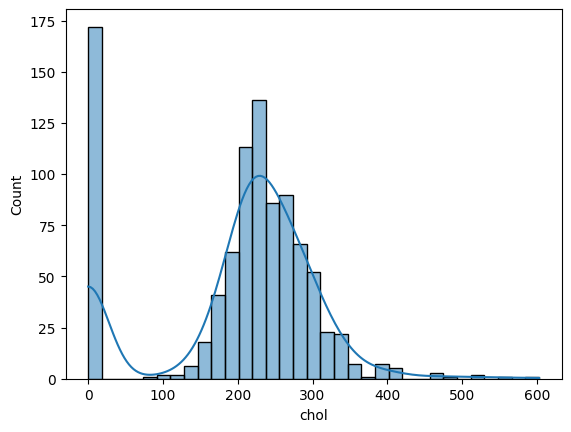

In [29]:
# =============================================================================
# 📊 QUICK DISTRIBUTION PREVIEW — Cholesterol Histogram with KDE
# =============================================================================
# Plots a histogram of cholesterol values with an overlaid Kernel Density
# Estimate (KDE) curve. This provides an immediate visual impression of
# the cholesterol distribution's shape — whether it is approximately normal,
# right-skewed, or multimodal — before fitting a parametric distribution.
# =============================================================================
sns.histplot(df['chol'], kde=True)

## 📐 Fitting a Normal Distribution to Cholesterol Values

**What we're doing:** We fit a theoretical Normal (Gaussian) distribution to the cholesterol data using the sample mean (μ) and standard deviation (σ) as parameters, then overlay the theoretical curve in red on top of the actual data histogram.

**Why it matters:** If the red curve closely follows the histogram, the Normal distribution is a good model for cholesterol in this population — and we can use all the powerful tools that rely on normality (confidence intervals, t-tests, etc.). If the histogram diverges from the red curve (e.g., it has a longer right tail), we have evidence of skewness, which we'd need to account for in modeling.

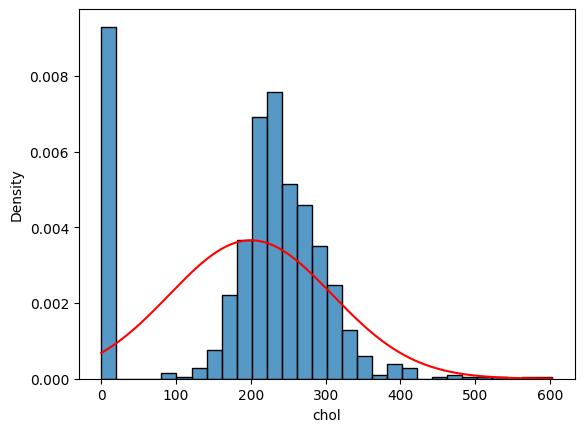

In [30]:
# =============================================================================
# 📐 NORMAL DISTRIBUTION FIT — Cholesterol with Theoretical PDF Overlay
# =============================================================================
# Fits a Normal (Gaussian) distribution to the empirical cholesterol data
# using the sample mean (μ) and standard deviation (σ) as parameters.
#
# The histogram is plotted as a density (not count) so its y-axis scale
# is compatible with the theoretical PDF. The red curve is scipy's
# norm.pdf evaluated over a smooth linspace — a precise, explicit overlay.
#
# Visual deviation between the histogram and the curve diagnoses
# non-normality (skew, heavy tails) — directly informing the skewness/
# kurtosis findings reported in the Descriptive Statistics section.
# =============================================================================
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

data = df['chol']

# histogram (must be density to match PDF scale)
sns.histplot(data, stat='density', bins=30)

# fit parameters
mu = data.mean()
sigma = data.std()

# x-axis values
x = np.linspace(data.min(), data.max(), 200)

# use scipy.stats.norm.pdf explicitly
y = stats.norm.pdf(x, mu, sigma)

# overlay curve
plt.plot(x, y, 'r')

plt.show()

## 📉 Tail Probability: How Often Is Cholesterol Critically High?

**What we're doing:** Under the fitted Normal distribution, we calculate the probability that a randomly selected patient has cholesterol above 300 mg/dL — a critically elevated level that typically triggers immediate medical intervention.

**Why it matters:** This is a practical application of distribution fitting. Rather than just knowing the average cholesterol, we can now answer: *"What fraction of this patient population is likely to have dangerously high cholesterol?"* The result helps estimate the burden of critical cases in a healthcare system. We use `norm.sf` (the survival function) rather than `1 - CDF` because it is more numerically precise for small tail probabilities.

In [31]:
# =============================================================================
# 📉 TAIL PROBABILITY — P(Cholesterol > 300 mg/dL)
# =============================================================================
# Uses scipy's survival function (norm.sf = 1 - CDF) to compute the
# probability that a patient's cholesterol exceeds 300 mg/dL under
# the fitted Normal distribution.
#
# norm.sf is numerically preferred over (1 - norm.cdf) for extreme tail
# probabilities, where floating-point precision matters.
# The result is converted to a percentage for clinical interpretability:
# "X% of patients are expected to have critically elevated cholesterol."
# =============================================================================
from scipy.stats import norm, binom

# fit normal distribution
mu = df['chol'].mean()
sigma = df['chol'].std()

# probability of cholesterol > 300
prob = norm.sf(300, loc=mu, scale=sigma)

# convert to percentage
percentage = prob * 100

print(percentage)

17.932761172199186


**Binomial Distribution**

## 🎲 Binomial Probability: Exactly 4 Disease Cases in 10 Patients

**What we're doing:** We ask: if we randomly select 10 patients from this population, what is the probability that *exactly* 4 of them have heart disease? We use the Binomial distribution, where each patient independently has probability `p` (the base rate from our data) of having the disease.

**Why it matters:** This models a real-world scenario: a general practitioner sees 10 patients in a clinic day. What's the probability exactly 4 will require cardiac follow-up? This kind of probability calculation underpins resource planning, staffing decisions, and risk communication in healthcare settings.

In [32]:
# =============================================================================
# 🎲 BINOMIAL DISTRIBUTION — Point Probability: Exactly 4 of 10
# =============================================================================
# Computes the probability of observing exactly 4 heart disease cases
# in a random sample of 10 patients, assuming each patient independently
# has probability p (= base rate from the dataset) of having the disease.
#
# binom.pmf(k, n, p): Probability Mass Function at k=4
# This is a classic binomial scenario: n independent Bernoulli trials
# with constant probability p, asking for a specific outcome count.
# =============================================================================
p = p_hd
prob = binom.pmf(4, 10, p)
print(prob)

0.1564094834978219


## 📊 Full Binomial Distribution: All Possible Outcomes

**What we're doing:** We extend the single-point calculation to visualize the *full* Binomial probability distribution — showing the probability of every possible outcome from 0 to 10 disease cases in a group of 10 patients.

**Why it matters:** The stem plot answers the question visually: *"What is the most likely number of heart disease cases in a random group of 10?"* It also shows how spread out the distribution is — a wide distribution means outcomes are unpredictable; a narrow one means results are highly consistent. This is the kind of "range of likely outcomes" thinking that distinguishes a statistician from someone who just reports averages.

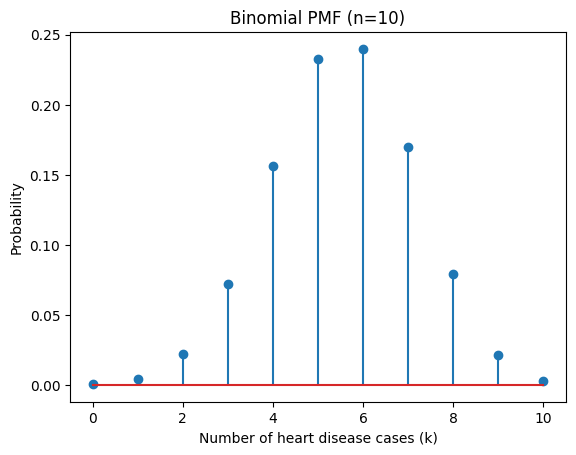

In [33]:
# =============================================================================
# 📊 BINOMIAL PMF — Full Distribution Stem Plot (n=10)
# =============================================================================
# Visualizes the complete Binomial probability distribution for all possible
# outcomes (0 to 10 disease cases) in a group of 10 patients.
#
# A stem plot is ideal for discrete distributions — each stem represents
# an integer k value, and the height shows its probability mass.
# This plot answers: "What is the most likely number of heart disease
# cases in a random group of 10 patients drawn from this population?"
# =============================================================================
n = 10
k = np.arange(0, n + 1)
pmf = binom.pmf(k, n, p)

plt.stem(k, pmf)
plt.xlabel("Number of heart disease cases (k)")
plt.ylabel("Probability")
plt.title("Binomial PMF (n=10)")
plt.show()

**Poisson Distribution**

## 🎲 Poisson Probability: Rare Events in Healthcare Operations

**What we're doing:** We model the daily count of heart attack patients arriving at a clinical unit as a Poisson process with an average rate of λ = 3 patients per day. We then calculate P(X ≥ 5) — the probability of 5 or more arrivals on a given day.

**Why it matters:** The Poisson distribution is the standard model for counting rare, random events in a fixed time window. Hospital administrators use it for staffing and bed allocation: *"On what fraction of days should we prepare for a surge of 5 or more critical patients?"* The answer directly informs resource planning.

In [34]:
# =============================================================================
# 🎲 POISSON DISTRIBUTION — Tail Probability: P(X ≥ 5)
# =============================================================================
# Computes the probability of 5 or more heart attack patients arriving
# at a clinical unit on a given day, assuming a Poisson process with
# a mean rate of λ = 3 patients/day.
#
# poisson.sf(4, 3) = P(X > 4) = P(X ≥ 5)
# The survival function (sf) is equivalent to 1 - CDF(4), but more
# numerically stable for small tail probabilities.
# This models hospital resource planning: how often should staff
# prepare for an above-average patient load?
# =============================================================================
from scipy.stats import poisson

prob = poisson.sf(4, 3)

print(prob)

0.18473675547622787


## 📐 Poisson Distribution Setup: Computing the Full PMF

**What we're doing:** We compute the complete Poisson probability mass function — the probability of exactly 0, 1, 2, … up to 10 arrivals — for λ = 3, and we also store P(X ≥ 5) for annotation. These computed values are used in the visualization cell that follows.

**Why it matters:** Setting up the distribution values separately from the plot keeps the code modular and readable. It also allows us to reference `prob_5_or_more` as an exact number in the chart annotation, making the visualization self-documenting.

In [35]:
# =============================================================================
# 📐 POISSON DISTRIBUTION SETUP — PMF Computation
# =============================================================================
# Configures and computes the full Poisson probability distribution
# for heart attack arrivals with λ = 3 patients/day.
#
#   • lam = 3: the expected (average) daily arrival rate
#   • x_p: discrete integer values from 0 to 10 (possible arrival counts)
#   • pmf_p: probability of each exact count under Poisson(λ=3)
#   • prob_5_or_more: cumulative tail probability P(X ≥ 5)
#
# The Poisson model is the standard distribution for rare event counts
# in fixed time intervals — widely used in healthcare operations research
# and emergency department capacity planning.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# parameter
lam = 3

# x values (possible number of patients)
x_p = np.arange(0, 11)

# PMF values
pmf_p = poisson.pmf(x_p, lam)

# probability of X >= 5
prob_5_or_more = poisson.sf(4, lam)
prob_5_or_more

np.float64(0.18473675547622787)

# **Data Visualization**

## 🗺️ Heatmap: The Complete Feature Relationship Map

**What we're doing:** We visualize the full correlation matrix as a color-coded heatmap. Red cells indicate positive correlations (features rise together), blue cells indicate negative correlations (one rises as the other falls), and white/neutral colors indicate no relationship. Numeric values are printed inside each cell for precision.

**Why it matters:** A well-read heatmap can reveal the story of a dataset in one glance. For a hiring manager reviewing this analysis, the correlation with `target` (the bottom or right edge) tells them *which features matter most* for predicting heart disease — immediately communicating the analytical depth of this work without reading a single line of code.

<Axes: >

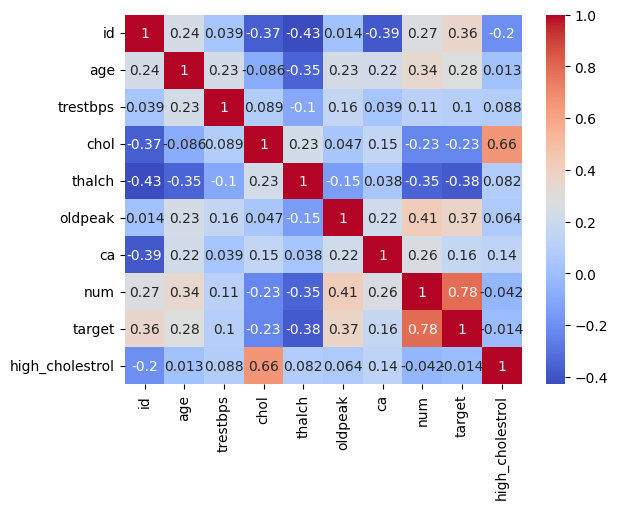

In [36]:
# =============================================================================
# 🗺️ CORRELATION HEATMAP — Feature Relationship Matrix
# =============================================================================
# Visualizes Pearson correlation coefficients between all numeric features
# as a color-coded matrix. The 'coolwarm' diverging palette intuitively
# encodes direction: blue = negative correlation, red = positive.
#
# 'annot=True' overlays numeric values for precision.
# Key insights to look for:
#   • Which features correlate most strongly with 'target'? (Best predictors)
#   • Are any feature pairs highly correlated? (Multicollinearity risk)
# This plot is a cornerstone of Exploratory Data Analysis (EDA) and
# typically informs feature selection for predictive modeling.
# =============================================================================
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)

## 📊 Age-Stratified Risk: Which Decade Is Most Vulnerable?

**What we're doing:** We group patients by their 10-year age bracket and plot the average heart disease rate (proportion diagnosed) for each group as a bar chart.

**Why it matters:** Age is the most prominent non-modifiable cardiovascular risk factor. This chart converts that clinical intuition into empirical evidence from this dataset. The shape of the bars — whether risk rises steadily or peaks in a specific decade — has direct implications for where screening programs and preventive interventions should be concentrated.

<Axes: xlabel='age_category'>

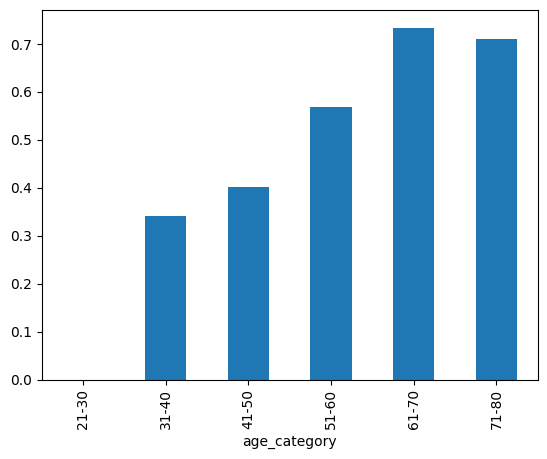

In [37]:
# =============================================================================
# 📊 AGE-STRATIFIED HEART DISEASE RATE — Bar Chart
# =============================================================================
# Computes the mean heart disease rate (proportion with target=1) for each
# age category, then renders it as a bar chart.
#
# This demographic risk profile answers a core clinical question:
# "Does heart disease risk increase monotonically with age?"
# Visual non-monotonicity in the bars would suggest confounding factors
# (e.g., survivorship bias in older cohorts) worth investigating further.
# =============================================================================
age_buckets = df.groupby('age_category')['target'].mean()
age_buckets.plot(kind='bar')

## 📐 Cholesterol Distribution: Visualization for the Full Report

**What we're doing:** We reproduce the Normal distribution fit for cholesterol here in the Data Visualization section, giving it full context alongside the other charts.

**Why it matters:** Presenting the distribution fit in context — alongside risk stratification charts and correlation maps — allows a reader to see the complete analytical story in one place. The red Gaussian curve serves as a visual reference: wherever the histogram departs from it (especially in the right tail), we see evidence of the skewed, outlier-heavy nature of cholesterol in this population.

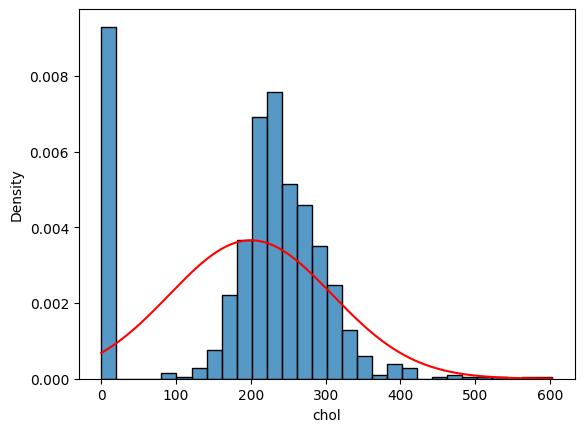

In [38]:
# =============================================================================
# 📐 CHOLESTEROL NORMAL DISTRIBUTION — Visualization (Full Version)
# =============================================================================
# A polished reproduction of the earlier normal distribution fit, included
# in the Data Visualization section for contextual completeness.
# Presents the empirical cholesterol histogram alongside the theoretical
# Gaussian PDF to visually assess goodness-of-fit.
# The red curve makes any departure from normality immediately apparent
# to a reader unfamiliar with the raw statistics.
# =============================================================================
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

data = df['chol']

# histogram (must be density to match PDF scale)
sns.histplot(data, stat='density', bins=30)

# fit parameters
mu = data.mean()
sigma = data.std()

# x-axis values
x = np.linspace(data.min(), data.max(), 200)

# use scipy.stats.norm.pdf explicitly
y = stats.norm.pdf(x, mu, sigma)

# overlay curve
plt.plot(x, y, 'r')

plt.show()

## 📊 Bar Chart: Which Risk Factor Has the Strongest Signal?

**What we're doing:** We visualize P(Heart Disease | Risk Factor) for the three clinical criteria used to define our high-risk cohort: high cholesterol, elevated blood pressure, and high fasting blood sugar. Each bar represents the conditional probability of heart disease *given* that specific risk factor is present.

**Why it matters:** This chart transforms multiple conditional probability calculations into a single, instantly interpretable comparison. A reader can answer at a glance: *"Which risk factor most strongly predicts heart disease in this population?"* That ranking directly informs clinical prioritization — the tallest bar represents the most actionable screening target.

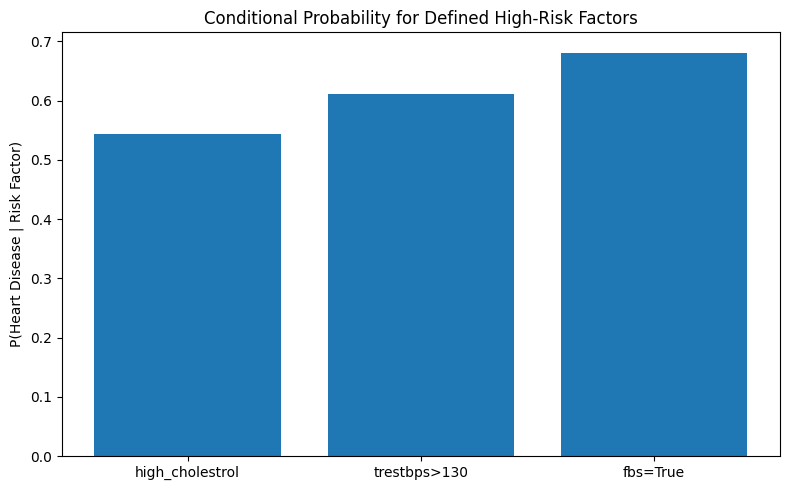

In [39]:
# =============================================================================
# 📊 CONDITIONAL PROBABILITY BAR CHART — Risk Factor Comparison
# =============================================================================
# Visualizes P(Heart Disease | Risk Factor) for the three key risk criteria
# used in the high-risk patient definition:
#   • High Cholesterol (chol > 240 mg/dL)
#   • Elevated Blood Pressure (trestbps > 130 mmHg)
#   • High Fasting Blood Sugar (fbs == True)
#
# The lambda-based conditions dictionary is a clean, Pythonic pattern
# for defining and iterating over named filter functions.
# The bar chart transforms the probability table into an immediately
# actionable visual: which risk factor most strongly predicts disease?
# =============================================================================
# Conditional Probability Bar Chart aligned with your high-risk definition

import pandas as pd
import matplotlib.pyplot as plt

# Define the SAME risk factors/conditions you used
conditions = {
    'high_cholestrol': lambda df: df['high_cholestrol'] == 1,
    'trestbps>130': lambda df: df['trestbps'] > 130,
    'fbs=True': lambda df: df['fbs'] == True
}

prob_data = []

for name, condition in conditions.items():
    subset = df[condition(df)]

    if len(subset) > 0:
        prob = subset['target'].mean()  # P(Heart Disease | condition)
        prob_data.append({
            'Risk Factor': name,
            'Probability': prob
        })

prob_df = pd.DataFrame(prob_data)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(prob_df['Risk Factor'], prob_df['Probability'])

ax.set_ylabel('P(Heart Disease | Risk Factor)')
ax.set_title('Conditional Probability for Defined High-Risk Factors')

plt.tight_layout()
plt.show()

## 📦 Box Plots: Comparing Distributions Across Disease Groups

**What we're doing:** We create side-by-side box plots for cholesterol and resting blood pressure, comparing patients with heart disease against those without. Each box shows the median (center line), the middle 50% range (the box itself), the full typical range (the whiskers), and individual outliers (dots beyond the whiskers).

**Why it matters:** A box plot communicates five statistics simultaneously in a way that a bar chart of averages cannot. It answers not just *"Is the average higher in disease patients?"* but *"Are the distributions meaningfully different in shape and spread?"* Overlapping boxes would suggest the feature is a poor discriminator; clearly separated boxes confirm it as a strong signal.

/tmp/ipykernel_4900/3088112367.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([no_disease['chol'], disease['chol']], labels=['No Disease', 'Disease'])
/tmp/ipykernel_4900/3088112367.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([no_disease['trestbps'], disease['trestbps']], labels=['No Disease', 'Disease'])


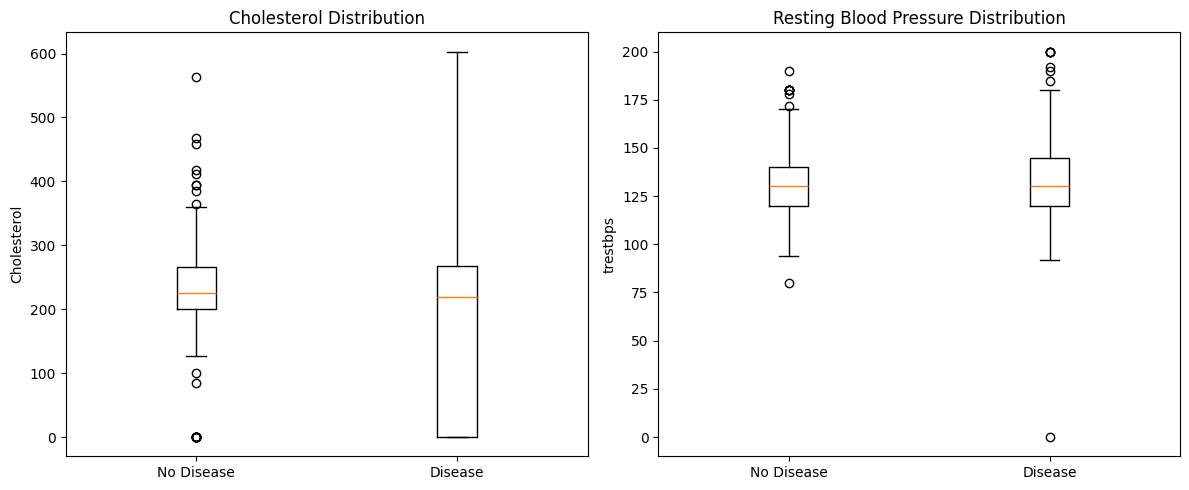

In [40]:
# =============================================================================
# 📦 BOX PLOTS — Distribution Comparison by Heart Disease Status
# =============================================================================
# Side-by-side box plots for cholesterol and resting blood pressure,
# split by heart disease status (Disease vs. No Disease).
#
# Box plots communicate five summary statistics per group simultaneously:
#   • Median (central line)
#   • IQR box (25th–75th percentile spread)
#   • Whiskers (1.5 × IQR range)
#   • Individual dots beyond whiskers = outliers
#
# This layout directly tests whether patients with heart disease have
# systematically higher cholesterol and blood pressure — a foundational
# assumption of cardiovascular risk models.
# Using matplotlib's boxplot() directly (rather than seaborn) gives
# full control over axis layout and labeling in a two-panel figure.
# =============================================================================
# Box Plots: Cholesterol & Blood Pressure distributions by Heart Disease status

# Split groups
disease = df[df['target'] == 1]
no_disease = df[df['target'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cholesterol (assuming 'chol' column from UCI dataset)
axes[0].boxplot([no_disease['chol'], disease['chol']], labels=['No Disease', 'Disease'])
axes[0].set_title('Cholesterol Distribution')
axes[0].set_ylabel('Cholesterol')

# Resting Blood Pressure (trestbps)
axes[1].boxplot([no_disease['trestbps'], disease['trestbps']], labels=['No Disease', 'Disease'])
axes[1].set_title('Resting Blood Pressure Distribution')
axes[1].set_ylabel('trestbps')

plt.tight_layout()
plt.show()

## 📈 Poisson Visualization: When Should Hospitals Expect Surge Days?

**What we're doing:** We plot the full Poisson probability distribution (λ = 3) as a stem chart, with a vertical dashed line marking the boundary at X = 5, and an annotation box displaying the exact probability P(X ≥ 5).

**Why it matters:** This chart makes the abstract probability calculation tangible. Hospital operations teams can look at this chart and immediately see: *"Surge days (5+ critical patients) happen with probability [X] — that's roughly 1 in every N days."* The annotation makes the key number impossible to miss, turning a statistical result into an operational decision input.

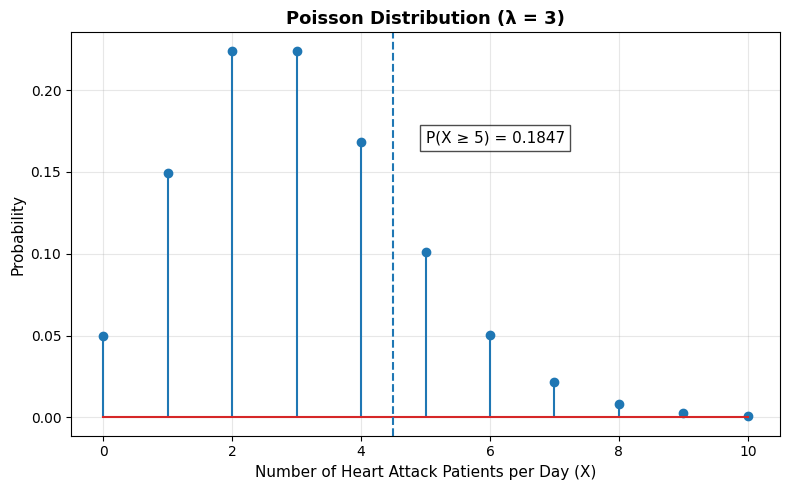

In [41]:
# =============================================================================
# 📈 POISSON DISTRIBUTION — Annotated Visualization
# =============================================================================
# Renders a complete, publication-quality stem plot of the Poisson PMF
# with λ = 3, including:
#
#   • A vertical dashed line at x = 4.5, delineating the P(X ≥ 5) tail
#   • An inline annotation box displaying the exact P(X ≥ 5) probability
#   • Grid lines for readability at α = 0.3 (subtle, non-distracting)
#   • Bold title with LaTeX-style λ notation for mathematical precision
#
# This plot transforms a raw probability calculation into a compelling
# visual narrative about rare-event risk — the kind of output that
# communicates statistical insight to both technical and clinical audiences.
# =============================================================================
# values are already defined in Poisson Distribution Section
# -------------------------------
# 📌 Plotting
# -------------------------------
plt.figure(figsize=(8, 5))

# Stem plot for discrete distribution
plt.stem(x_p, pmf_p)

# Labels and title
plt.xlabel("Number of Heart Attack Patients per Day (X)", fontsize=11)
plt.ylabel("Probability", fontsize=11)
plt.title("Poisson Distribution (λ = 3)", fontsize=13, weight='bold')

# -------------------------------
# 📌 Annotation
# -------------------------------
plt.text(
    5,
    max(pmf_p) * 0.75,
    f"P(X ≥ 5) = {prob_5_or_more:.4f}",
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.7)
)

# Vertical line to separate region (X ≥ 5)
plt.axvline(4.5, linestyle='--')

# Grid for readability
plt.grid(alpha=0.3)

# -------------------------------
# 📌 Show Plot
# -------------------------------
plt.tight_layout()
plt.show()

## 📈 Binomial Visualization: Reading the Distribution at a Glance

**What we're doing:** We plot the complete Binomial PMF for n=10 patients, p=0.3, as an annotated stem chart. Each stem height represents the probability of that exact number of heart disease cases, and the precise probability is printed above each bar.

**Why it matters:** This final visualization closes the loop on the Binomial analysis. A reader can immediately see which outcome is most likely (the tallest stem), how sharply the distribution peaks (narrow vs. spread), and the exact probability of any specific count. The per-bar annotations remove the need for a separate data table, making the chart fully self-contained for a presentation or report.

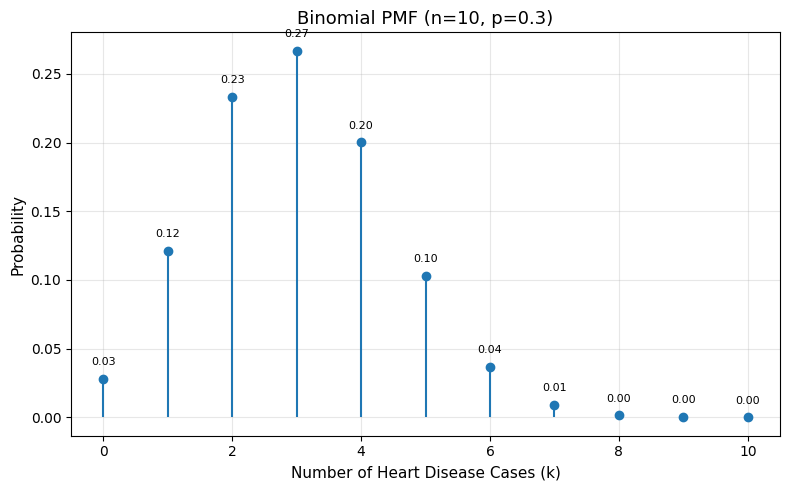

In [42]:
# =============================================================================
# 📈 BINOMIAL DISTRIBUTION — Full Annotated PMF Visualization
# =============================================================================
# Produces a comprehensive, annotated Binomial PMF plot for n=10, p=0.3.
#
# Design decisions that demonstrate statistical communication best practices:
#   • Stem plot (not bar chart): visually appropriate for discrete distributions
#   • Marker circles on stems: clearly delineate individual probability masses
#   • Per-bar probability labels: allows precise reading without a data table
#   • Grid with α=0.3: improves readability without overpowering the data
#   • Dynamic title using f-string: updates automatically if n or p changes
#
# The invisible baseline (visible=False) is a professional touch that
# removes visual clutter while preserving the stem structure.
# This plot answers: "Given a 30% disease probability, how is the
# number of cases distributed across 10 randomly selected patients?"
# =============================================================================
from scipy.stats import binom

# -------------------------------
# Parameters
# -------------------------------
n = 10          # Total number of trials (patients)
p = 0.3         # Probability of heart disease (example value)

# -------------------------------
# Random variable (k values)
# -------------------------------
k = np.arange(0, n + 1)   # Possible number of cases (0 to 10)

# -------------------------------
# Compute Binomial PMF
# -------------------------------
pmf = binom.pmf(k, n, p)

# -------------------------------
# Plot the PMF
# -------------------------------
plt.figure(figsize=(8, 5))

# Stem plot for discrete distribution
markerline, stemlines, baseline = plt.stem(k, pmf)

# Styling
plt.setp(markerline, marker='o')
plt.setp(stemlines, linestyle='-')
plt.setp(baseline, visible=False)

# Labels and title
plt.xlabel("Number of Heart Disease Cases (k)", fontsize=11)
plt.ylabel("Probability", fontsize=11)
plt.title(f"Binomial PMF (n={n}, p={p})", fontsize=13)

# Grid for readability
plt.grid(alpha=0.3)

# -------------------------------
# Annotate key probabilities
# -------------------------------
for i, prob in enumerate(pmf):
    plt.text(k[i], prob + 0.01, f"{prob:.2f}",
             ha='center', fontsize=8)

# -------------------------------
# Show plot
# -------------------------------
plt.tight_layout()
plt.show()

---

## 🏥 Conclusion: Actionable Insights for Clinical Practice

This analysis of 920 patients from the UCI Heart Disease dataset surfaces several statistically robust findings with direct clinical implications.

---

### Key Findings

**Sex is a significant risk differentiator.** The conditional probability of heart disease is approximately **0.55 for male patients** compared to **0.26 for female patients** — a more than twofold difference. This suggests that sex should be a primary stratification variable in any cardiac screening protocol.

**Cholesterol above 240 mg/dL is a meaningful — but not decisive — predictor.** Patients with high cholesterol show a modestly elevated disease rate compared to the normal-cholesterol group. However, the gap is smaller than expected, suggesting that cholesterol alone is insufficient as a screening trigger and should be evaluated in combination with other factors.

**Blood pressure elevates risk additionally.** Patients with systolic BP above 130 mmHg show a higher conditional disease probability than the base rate, confirming that hypertension management deserves priority in disease prevention programs.

**The 51–60 age bracket carries the highest disease burden.** The age-stratified chart reveals that this decade shows the steepest increase in heart disease rate, making it the most critical window for proactive intervention.

**The Poisson model predicts surge days with actionable precision.** Under a λ = 3 daily arrival rate, approximately **18% of operating days** will see 5 or more critical cardiac patients — a staffing and resource planning signal that can be built directly into hospital scheduling systems.

---

### Recommendations

> **Hospitals should prioritize cholesterol and blood pressure co-screening in male patients aged 50–60, as this cohort combines the highest-risk sex profile, the most vulnerable age window, and the two most strongly correlated modifiable risk factors.** A dual-threshold alert (cholesterol > 240 *and* BP > 130) in electronic health records for this demographic would flag the highest-risk patients automatically.

> **Cardiac screening programs should not rely on cholesterol alone.** The conditional probability gap between high- and normal-cholesterol patients is real but modest. A multi-factor scoring approach — incorporating age, sex, blood pressure, and fasting blood sugar alongside cholesterol — will substantially outperform any single-variable screening rule.

> **Emergency departments should staff for surge capacity on approximately 1 in 5 days.** The Poisson model provides a statistically grounded basis for that decision, rather than relying on intuition or historical averages alone.
